In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

### Problem 4
Submit this ipynb

In [2]:
imname='M84.fits'
imhdr=fits.getheader(imname)
imdata=fits.getdata(imname)
X, Y = np.meshgrid( np.arange(1,imhdr['NAXIS1']+1), np.arange(1,imhdr['NAXIS2']+1) )

In [3]:
#constants from region selected
npix = 963
mean = 2.05538
median = 1.9425
stddev = 4.48441

sky_error = stddev / np.sqrt(npix)

#constants determined by my understanding of the center
x_center = 713.5
y_center = 739.33

In [4]:
#calculating radius distances from X and Y
R = np.sqrt( (X-x_center)**2 + (Y-y_center)**2 )
R=R.flatten()
pixvals=imdata.flatten()

#correcting for errors due to the sky
corrected_pixval = pixvals - median

In [5]:
# Burrell Schmidt Telescope optics
pixscale = 1.45  # arcsec/pixel
zeropoint = 28.60
pixel_area = pixscale**2  # arcsec^2

In [6]:
#binning constants
bin_edges = np.arange(0,500,10)
print(bin_edges)

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350
 360 370 380 390 400 410 420 430 440 450 460 470 480 490]


In [7]:
#bin for mean (avg)
stat='mean'
bin_yavg, bin_edges, bin_num = binned_statistic(R,corrected_pixval,statistic=stat,bins=bin_edges)
bin_centers=0.5*(bin_edges[1:]+bin_edges[:-1])
mu_mean = -2.5 * np.log10(bin_yavg / pixel_area) + zeropoint

In [8]:
#bin for median
stat='median'
bin_ymed, bin_edges, bin_num = binned_statistic(R,corrected_pixval,statistic=stat,bins=bin_edges)
bin_centers=0.5*(bin_edges[1:]+bin_edges[:-1])
mu_median = -2.5 * np.log10(bin_ymed / pixel_area) + zeropoint

#radius in arcsec
radius_arcsec = bin_centers * pixscale

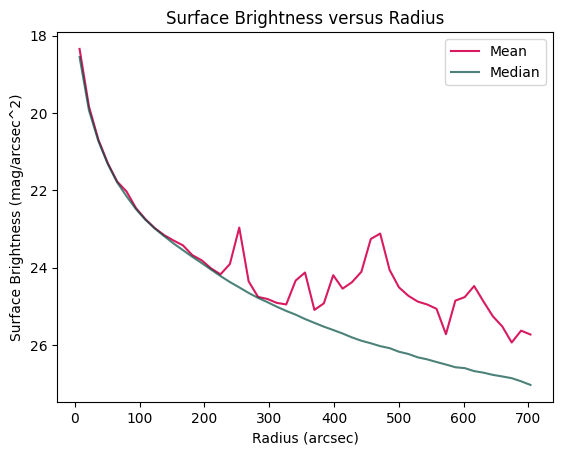

In [9]:
#plot 1
plt.figure()
plt.plot(radius_arcsec, mu_mean, label='Mean', color = "#D81B60")
plt.plot(radius_arcsec, mu_median, label='Median', color = "#004D40", alpha = 0.7)
plt.gca().invert_yaxis()
plt.xlabel("Radius (arcsec)")
plt.ylabel("Surface Brightness (mag/arcsec^2)")
plt.title("Surface Brightness versus Radius")
plt.legend()

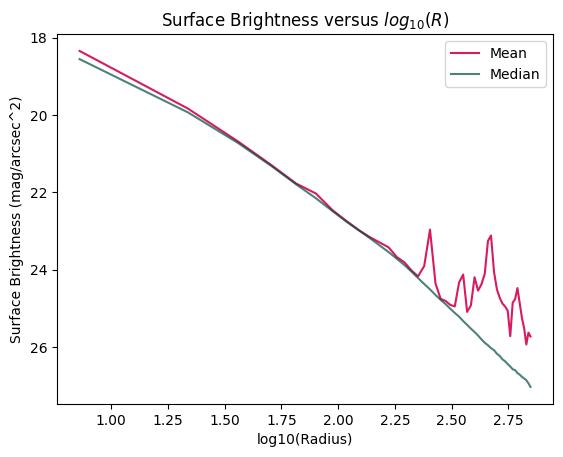

In [10]:
#plot 2
plt.plot(np.log10(radius_arcsec), mu_mean, label='Mean', color = "#D81B60")
plt.plot(np.log10(radius_arcsec), mu_median, label='Median', color = "#004D40", alpha = 0.7)
plt.gca().invert_yaxis()
plt.xlabel("log10(Radius)")
plt.ylabel("Surface Brightness (mag/arcsec^2)")
plt.title("Surface Brightness versus $log_{10}(R)$")
plt.legend()

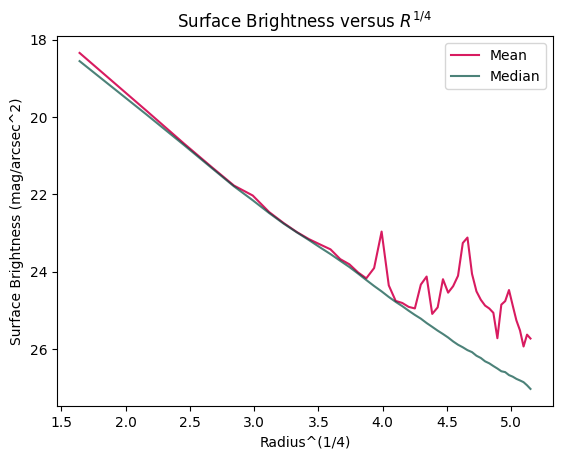

In [11]:
#plot 3
plt.plot(radius_arcsec**0.25, mu_mean, label='Mean', color = "#D81B60")
plt.plot(radius_arcsec**0.25, mu_median, label='Median', color = "#004D40", alpha = 0.7)
plt.gca().invert_yaxis()
plt.xlabel("Radius^(1/4)")
plt.ylabel("Surface Brightness (mag/arcsec^2)")
plt.title("Surface Brightness versus $R^{1/4}$")
plt.legend()

In [12]:
#running total of all the counts
cumulative_counts = []
running_total = 0

for i in range(len(bin_ymed)):
    
    r_in = bin_edges[i]
    r_out = bin_edges[i+1]
    
    annulus_area = np.pi * (r_out**2 - r_in**2)
    counts_annulus = bin_ymed[i] * annulus_area
    
    running_total += counts_annulus
    cumulative_counts.append(running_total)

cumulative_counts = np.array(cumulative_counts)

print("Total counts =", running_total)

Total counts = 61394444.24724457


In [13]:
#mag calc
m_total = -2.5*np.log10(running_total) + 28.60
print("Total V magnitude =", m_total)

Total V magnitude = 9.129677318968465


In [14]:
#half-light calc
half_light_value = running_total / 2

index = np.where(cumulative_counts >= half_light_value)[0][0]

r_half_pixels = 0.5*(bin_edges[index] + bin_edges[index+1])

r_half_arcsec = r_half_pixels * pixscale

print("Half-light radius (pixels) =", r_half_pixels)
print("Half-light radius (arcsec) =", r_half_arcsec)

Half-light radius (pixels) = 75.0
Half-light radius (arcsec) = 108.75
